<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Bet sizing: closed-form OU trading rules
    </h1>
  </div>
</div>

For a **mean-reverting (Ornstein-Uhlenbeck)** signal, de Prado finds the
optimal profit-take / stop-loss by a **Monte-Carlo grid** over PT/SL pairs (AFML
ch.13): simulate many paths, score each pair, pick the grid argmax. That carries
simulation noise, costs compute, and is limited by grid resolution. The
**Lipton-Lopez de Prado (2020) closed form** gives the exact optimum from
first-passage theory - no simulation.

*Baseline (Monte-Carlo grid) -> where it breaks (noise / resolution) -> closed form.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Backtest: fit_ornstein_uhlenbeck, ou_rule_metrics,
    optimal_ou_trading_rule, hit_upper_probability, mean_exit_time

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. Simulate and fit an OU process
Always check the OU fit (`r2`, half-life) before trusting either rule.

In [2]:
rng = MersenneTwister(0)
T = 4000; theta_true = 0.05; sigma_true = 0.1
y = zeros(T)
for t in 2:T
    y[t] = y[t-1] - theta_true * y[t-1] + sigma_true * randn(rng)
end
fit = fit_ornstein_uhlenbeck(y)
println("fitted theta=", round(fit.theta, digits=4), "  sigma=", round(fit.sigma, digits=4),
        "  half-life=", round(fit.half_life, digits=1), "  r2=", round(fit.r2, digits=3))

fitted theta=0.0588  sigma=0.1026  half-life=11.8  r2=0.889


## 2. The exact return-rate surface and its optimum
The objective is expected net return per unit time, `E[gain]/E[tau]`. The
closed-form optimum maximizes it with no simulation noise.

optimal profit-take = 0.25   stop-loss = 3.996
max return rate = 0.05627   hit-prob = 1.0   E[holding] = 4.4


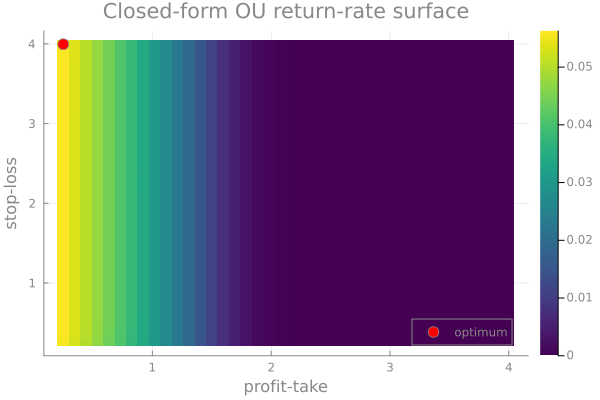

In [3]:
th, sg, eg = fit.theta, fit.sigma, 1.0
pts = range(0.25, 4.0; length = 40)
sls = range(0.25, 4.0; length = 40)
surface = [ou_rule_metrics(pt, sl, th, sg, eg).return_rate for sl in sls, pt in pts]
opt = optimal_ou_trading_rule(th, sg, eg)
println("optimal profit-take = ", round(opt.profit_take, digits = 3),
        "   stop-loss = ", round(opt.stop_loss, digits = 3))
println("max return rate = ", round(opt.return_rate, digits = 5),
        "   hit-prob = ", round(opt.hit_probability, digits = 3),
        "   E[holding] = ", round(opt.expected_holding_time, digits = 1))
heatmap(collect(pts), collect(sls), surface; xlabel = "profit-take", ylabel = "stop-loss",
        title = "Closed-form OU return-rate surface", color = :viridis)
scatter!([opt.profit_take], [opt.stop_loss]; label = "optimum", ms = 6, color = :red)

## When to use / when NOT (from `appraisals/23_verdict.md`)
**Prefer the closed-form OU rule over the Monte-Carlo grid whenever the OU model
is used** - it reproduces the grid optimum within resolution, 18-350x faster, with
no simulation noise. It **degrades in step with the grid off-model** (no robustness
to misspecification), so **check the OU fit at decision time** (the `r2` /
half-life above). Objective: expected net return per unit time. (The Julia
optimizer uses a coarse-to-fine grid search in place of SciPy L-BFGS-B.)